Shape: (545, 13)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing Values
price               0
area                0
bedrooms            0
bathrooms           0
stories     

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


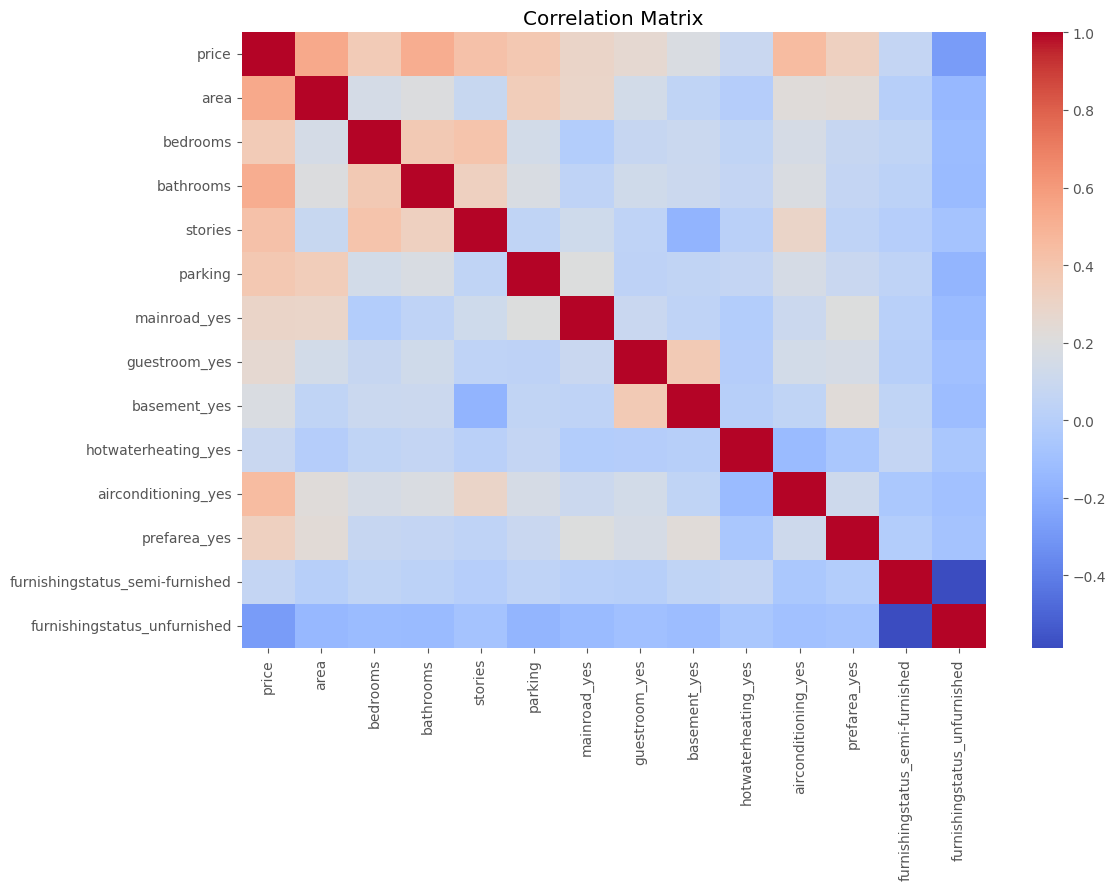

Training Shape: (436, 13)
Testing Shape: (109, 13)
Model Trained Successfully
Mean Absolute Error: 970043.4039201636
Mean Squared Error: 1754318687330.6638
R² Score: 0.6529242642153184


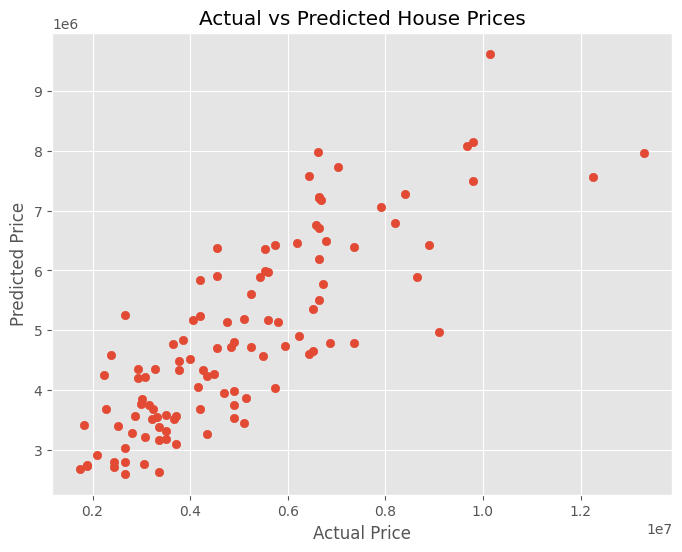

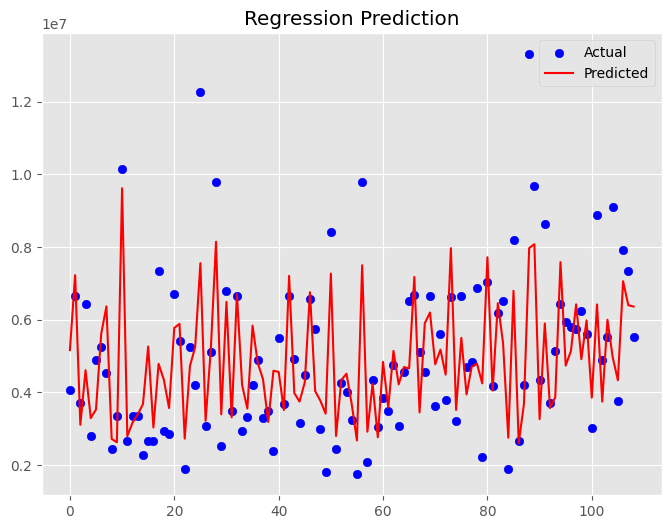

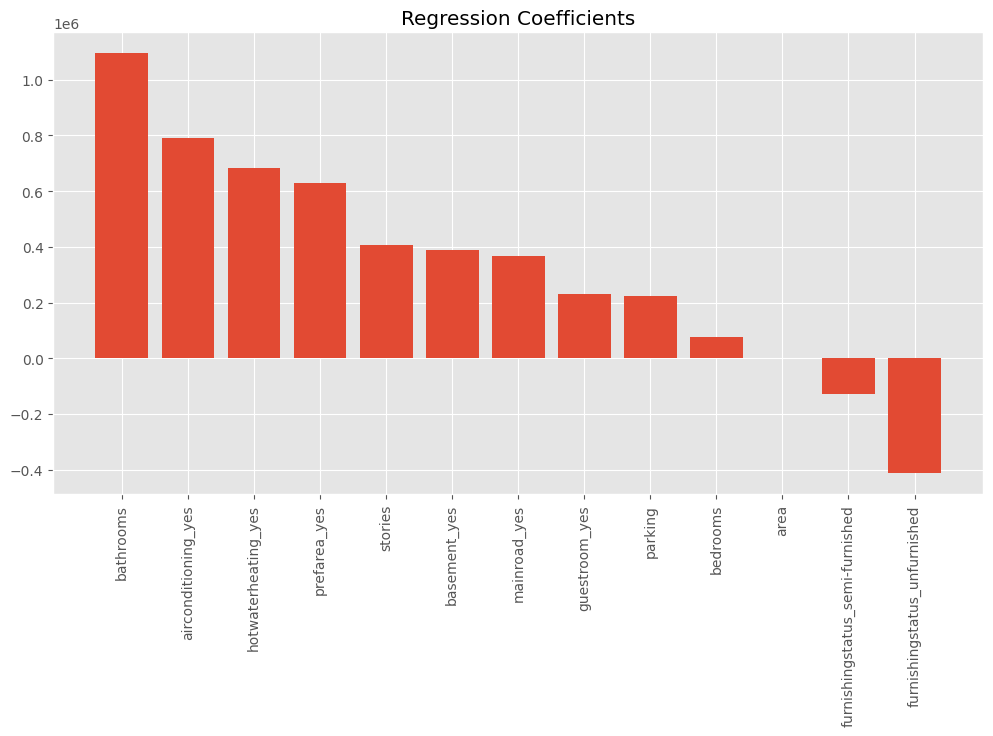

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("ggplot")

#Load Dataset
df = pd.read_csv("Housing.csv")
df.head()

#Explore Dataset
print("Shape:", df.shape)
print("\nDataset Information")
df.info()
print("\nMissing Values")
print(df.isnull().sum())
print("\nStatistical Summary")
display(df.describe())

#Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)
print(df.isnull().sum())

#Encode Categorical Columns
categorical_columns = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
df.head()

#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#Prepare Features and Target
X = df.drop("price", axis=1)
y = df["price"]

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

#Train Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

#Prediction
y_pred = model.predict(X_test)

y_pred[:10]

#Model Evaluation
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("R² Score:", r2)

#Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

#Regression Line
plt.figure(figsize=(8,6))

plt.scatter(range(len(y_test)), y_test, color="blue", label="Actual")

plt.plot(range(len(y_pred)), y_pred, color="red", label="Predicted")

plt.legend()

plt.title("Regression Prediction")

plt.show()

#Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

coefficients

#Feature Importance
plt.figure(figsize=(12,6))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.xticks(rotation=90)

plt.title("Regression Coefficients")

plt.show()